# Predicting Rocket Launch Delays
## Notebook 02 · From predictions to decisions

**Prepared and presented by Dr. Mohammed Hussin Talafha**  
Postdoctoral Research Fellow · University of Sharjah  
**الدكتور محمد حسين طلافحة — التنبؤ بتأخيرات إطلاق الصواريخ**

**Rocket Revolution · World Space Week 2026 · SSAH**  
Wednesday, 7 October 2026 · **12:00–13:00 UAE time (UTC+4)** · **60 minutes**

A beginner-friendly lab: make a prediction, run a cell, change something, explain what happened.
Work alone or in pairs. No previous machine-learning experience is required.

> **Our mission:** one hour before a fictional launch, predict whether it will
> fail to lift off within 15 minutes after its scheduled time.
> All records are **simulated**, including the rockets, launch pads and outcomes.
> Model scores describe this classroom simulation; they do not establish real launch reliability.

### What you will be able to do

Compare a decision tree with a random forest, balance missed delays against false
alarms, evaluate a fixed model on unseen attempts, and communicate the limits of its predictions.

| Minutes | Activity | Your contribution |
|---|---|---|
| 00–05 | Recap and fresh start | Rebuild the same data splits |
| 05–15 | Prepare mixed inputs | Identify numeric and category inputs |
| 15–25 | Compare models | Choose using validation results |
| 25–35 | Choose an alert threshold | Balance two kinds of error |
| 35–43 | Open the final test set | Interpret a confusion matrix |
| 43–55 | Launch scenario laboratory | Change inputs and explain the result |
| 55–60 | Submit a mini report | Save evidence and state a limitation |

### 00–05 · Recap and fresh start

Start a new kernel and run from the top. This notebook includes all code needed to
retrain its own models; notebook 01 does not need to have run first.
Choose **Python (Rocket Workshop)** and use **Shift+Enter**.

We predict `delayed = 1` when the fictional attempt is scrubbed or lifts off more than
15 minutes after the original schedule, using information available one hour before that schedule.
The 960 rows are **simulated**, and all vehicle and pad names are fictional.

**Recap question:** why can't `actual_delay_minutes` be a model input?

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display

SEED = 2026
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 14, "axes.labelsize": 11,
    "font.size": 10, "axes.titlepad": 12,
    "axes.prop_cycle": plt.cycler(color=["#146C94", "#E08028", "#428C72"]),
})
print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")
print("Ready. Data and models stay inside this workspace.")

Python 3.12.14 | pandas 2.2.3 | scikit-learn 1.8.0
Ready. Data and models stay inside this workspace.


In [2]:
# Find the repository whether the kernel starts in its root or notebooks/.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "data/synthetic_launch_attempts.csv").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook inside the workshop repository; data/synthetic_launch_attempts.csv is required.")

data = pd.read_csv(ROOT / "data/synthetic_launch_attempts.csv", parse_dates=[
    "scheduled_launch_utc", "prediction_time_utc", "outcome_recorded_utc"
]).sort_values("scheduled_launch_utc").reset_index(drop=True)
assert len(data) == 960 and data["mission_id"].is_unique
assert set(data["delayed"]) == {0, 1}
assert data["scheduled_launch_utc"].is_monotonic_increasing
assert ((data["scheduled_launch_utc"] - data["prediction_time_utc"]) == pd.Timedelta(hours=1)).all()
expected_label = (data["scrubbed"].eq(1) | data["actual_delay_minutes"].gt(15)).astype(int)
assert data["delayed"].equals(expected_label)

# Fixed, chronological split: earlier examples teach; later examples assess.
train = data.iloc[:576].copy()       # 60%: training
valid = data.iloc[576:768].copy()    # 20%: practice exam (validation)
test = data.iloc[768:].copy()        # 20%: final exam, used only in notebook 02
assert train["outcome_recorded_utc"].max() < valid["prediction_time_utc"].min()
assert valid["outcome_recorded_utc"].max() < test["prediction_time_utc"].min()
assert set(train.mission_id).isdisjoint(valid.mission_id)
assert set(train.mission_id).isdisjoint(test.mission_id)
assert set(valid.mission_id).isdisjoint(test.mission_id)
print(f"{len(data)} fictional attempts | train {len(train)} | validation {len(valid)} | test {len(test)}")

960 fictional attempts | train 576 | validation 192 | test 192


### 05–15 · More information, without information from the future

This time we use six numeric inputs and two categories. Extra inputs are only
helpful if their information generalises beyond the examples used to train.

- **Median imputation:** fill unknown numeric values using training medians.
- **One-hot encoding:** turn a category such as `Coastal Pad` into 0/1 columns.
- **Pipeline:** learn these transformations on the training split and reuse them unchanged.

The names of the pads and vehicles describe the attempt before launch. Their effects
here were invented for teaching; they do not rank real vehicles or locations.

In [3]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

NUMERIC = ["forecast_wind_kmh", "forecast_rain_pct", "forecast_lightning_pct",
           "forecast_cloud_pct", "temperature_c", "open_technical_items"]
CATEGORICAL = ["launch_pad", "vehicle"]
FEATURES = NUMERIC + CATEGORICAL
FORBIDDEN = {"delayed", "actual_delay_minutes", "scrubbed", "outcome_recorded_utc"}
assert not set(FEATURES) & FORBIDDEN
X_train, y_train = train[FEATURES], train["delayed"]
X_valid, y_valid = valid[FEATURES], valid["delayed"]

preprocess = ColumnTransformer([
    ("numbers", SimpleImputer(strategy="median"), NUMERIC),
    ("categories", Pipeline([
        ("fill", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), CATEGORICAL),
])
display(X_train.head())
print("Each model will get its own copy of this preprocessing recipe.")

,forecast_wind_kmh,forecast_rain_pct,forecast_lightning_pct,forecast_cloud_pct,temperature_c,open_technical_items,launch_pad,vehicle
0,10.9,23.0,15.9,41.4,29.4,0,Inland Pad,Aster-1
1,24.3,21.9,16.9,32.2,23.0,1,Coastal Pad,Aster-1
2,39.1,15.7,10.2,61.4,22.8,0,Coastal Pad,Aster-1
3,NaN,5.7,18.4,47.3,26.7,1,Inland Pad,Lyra-2
4,30.9,23.8,0.0,0.0,34.0,0,Coastal Pad,Aster-1


Each model will get its own copy of this preprocessing recipe.


**YOUR TURN 1:** which columns use percentages, which count items, and which are
names? If a new vehicle name appears later, how should we describe the uncertainty?

<details><summary>Hint / check your reasoning</summary>
Rain and lightning are forecast probabilities; cloud cover is an area fraction, not
a probability of rain. Technical items are counts. An unseen vehicle is not validated
by our training sample. Encoding it without an error does not make its prediction reliable.
</details>

### 15–25 · One tree or a forest?

A **random forest** combines many trees trained with different samples and feature
choices. Combining them can reduce the instability of a single tree. It can still
make mistakes, and it is not guaranteed to win.

For a fair comparison in this notebook, the baseline, tree and forest receive the
**same eight inputs and the same split**. The tree here has more inputs than notebook 01.

**Metrics:** accuracy counts all correct predictions; recall measures caught delays;
precision measures how often a delay flag is correct; F1 balances precision and recall.
ROC AUC measures ranking across thresholds (0.5 is chance-level ranking).
We use **validation F1 at threshold 0.50** to select a model, then choose a threshold.
That choice makes validation scores optimistic; the untouched test estimates the final workflow.

In [4]:
def score_predictions(y_true, probability, threshold=0.5):
    prediction = (np.asarray(probability) >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probability),
    }

candidates = {
    "Majority baseline": DummyClassifier(strategy="most_frequent"),
    "Decision tree": DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=SEED),
    "Random forest": RandomForestClassifier(n_estimators=150, max_depth=7,
                                           min_samples_leaf=8, random_state=SEED, n_jobs=2),
}
models, validation_probabilities, rows = {}, {}, []
for name, estimator in candidates.items():
    model = Pipeline([("prepare", clone(preprocess)), ("model", estimator)])
    model.fit(X_train, y_train)
    probability = model.predict_proba(X_valid)[:, 1]
    models[name] = model
    validation_probabilities[name] = probability
    rows.append({"model": name, **score_predictions(y_valid, probability)})
validation_scores = pd.DataFrame(rows).set_index("model")
display(validation_scores.round(3))

chosen_name = validation_scores["f1"].idxmax()  # Deterministic first-in-list tie break.
chosen_model = models[chosen_name]
valid_probability = validation_probabilities[chosen_name]
print("Selected using validation F1 at 0.50:", chosen_name)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Majority baseline,0.562,0.000,0.00,0.000,0.500
Decision tree,0.641,0.595,0.56,0.577,0.693
Random forest,0.661,0.627,0.56,0.591,0.751


Selected using validation F1 at 0.50: Random forest


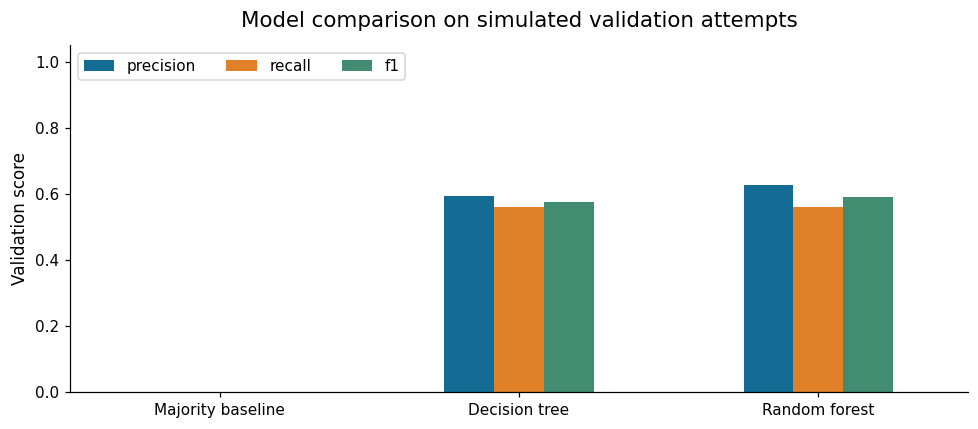

In [5]:
ax = validation_scores[["precision", "recall", "f1"]].plot.bar(figsize=(9, 4), rot=0)
ax.set(ylim=(0, 1.05), ylabel="Validation score", xlabel="", title="Model comparison on simulated validation attempts")
ax.legend(loc="upper left", ncol=3)
plt.tight_layout()
plt.show()

**YOUR TURN 2:** name the selected model and quote one advantage and one remaining
weakness from the table. Do not assume a more complex model must be better.

### 25–35 · What should trigger an alert?

A model returns a score between 0 and 1. We raise a **classroom delay flag** when
that score is at least a chosen threshold. A threshold changes the decision, not the model.

| Actual outcome | No flag | Flag |
|---|---|---|
| Within 15 minutes | Correct no-flag (TN) | False alarm (FP) |
| Delayed / scrubbed | Missed delay (FN) | Caught delay (TP) |

For this exercise, a missed delay costs **3 points** and a false alarm costs **1 point**.
These are invented planning costs, not money or launch safety rules. We minimise
`3 × missed delays + 1 × false alarms` on validation data only.

**Before running:** will lowering the threshold catch more delays? What happens to false alarms?

In [6]:
# YOUR TURN 3: try missed_delay_cost = 1, 3 and 5 BEFORE opening the final test.
missed_delay_cost = 3
false_alarm_cost = 1
threshold_rows = []
for threshold in np.round(np.arange(0.10, 0.91, 0.05), 2):
    flags = (valid_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_valid, flags, labels=[0, 1]).ravel()
    threshold_rows.append({
        "threshold": threshold, "missed_delays": int(fn), "false_alarms": int(fp),
        "precision": precision_score(y_valid, flags, zero_division=0),
        "recall": recall_score(y_valid, flags, zero_division=0),
        "cost_points": int(missed_delay_cost * fn + false_alarm_cost * fp),
    })
threshold_table = pd.DataFrame(threshold_rows)
best_row = threshold_table.sort_values(["cost_points", "threshold"]).iloc[0]
selected_threshold = float(best_row["threshold"])  # Prefer lower threshold when costs tie.
display(threshold_table.round(3))
print(f"Validation-selected threshold: {selected_threshold:.2f}")

,threshold,missed_delays,false_alarms,precision,recall,cost_points
0,0.10,1,101,0.451,0.988,104
1,0.15,2,90,0.477,0.976,96
2,0.20,3,79,0.506,0.964,88
3,0.25,5,64,0.552,0.940,79
4,0.30,9,58,0.564,0.893,85
5,0.35,14,47,0.598,0.833,89
6,0.40,21,43,0.594,0.750,106
7,0.45,30,34,0.614,0.643,124
8,0.50,37,28,0.627,0.560,139
9,0.55,42,23,0.646,0.500,149


Validation-selected threshold: 0.25


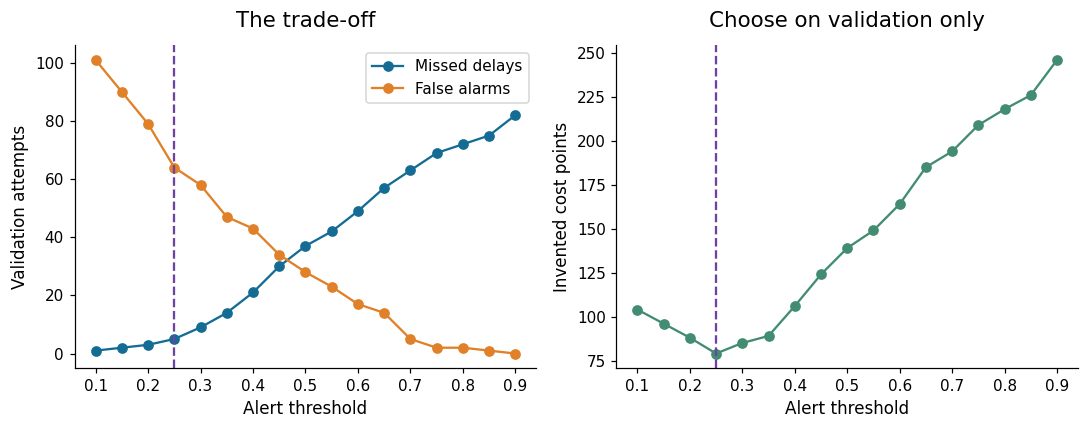

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(threshold_table.threshold, threshold_table.missed_delays, "o-", label="Missed delays")
axes[0].plot(threshold_table.threshold, threshold_table.false_alarms, "o-", label="False alarms")
axes[0].set(xlabel="Alert threshold", ylabel="Validation attempts", title="The trade-off")
axes[0].legend()
axes[1].plot(threshold_table.threshold, threshold_table.cost_points, "o-", color="#428C72")
axes[1].set(xlabel="Alert threshold", ylabel="Invented cost points", title="Choose on validation only")
for ax in axes:
    ax.axvline(selected_threshold, color="#6F42A1", ls="--", label="Selected")
plt.tight_layout()
plt.show()

**Checkpoint:** with fixed predictions, reducing the threshold cannot reduce the
number of flags. It usually catches more delays and creates more false alarms.
The selected threshold is the best on our small grid for this validation sample and cost choice.
It is not universally optimal, and model scores are not verified real-world probabilities.

### 35–43 · Freeze the choice and open the final test

**Stop tuning now.** Write down the selected model, threshold and cost ratio.
The next cell scores the **same trained model**, with that threshold, on later unseen attempts.
We do not refit on validation because that would change the model whose threshold we chose.
The fixed majority baseline is included as a reference, not as another tuning candidate.

After reading these test results, changing the model to improve them would turn this
test into another validation set. A second genuine final evaluation would need new data.

,threshold,accuracy,precision,recall,f1,roc_auc,missed_delays,false_alarms,cost_points
model,,,,,,,,,
Majority baseline,0.50,0.531,0.000,0.000,0.000,0.500,90,0,270
Random forest (fixed choice),0.25,0.641,0.573,0.911,0.704,0.829,8,61,85


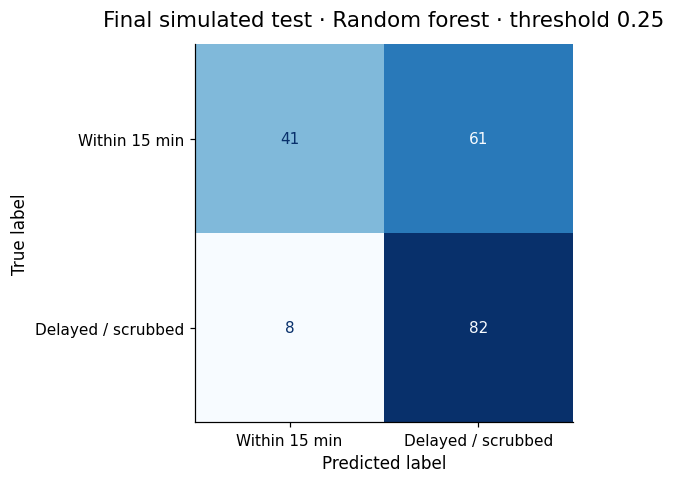

Of 90 delayed/scrubbed attempts, we caught 82 and missed 8.
False alarms: 61 among 102 attempts that launched within 15 minutes.


In [8]:
X_test, y_test = test[FEATURES], test["delayed"]
test_probability = chosen_model.predict_proba(X_test)[:, 1]
test_flags = (test_probability >= selected_threshold).astype(int)
baseline_test_probability = models["Majority baseline"].predict_proba(X_test)[:, 1]

test_rows = []
for label, probability, threshold in [
    ("Majority baseline", baseline_test_probability, 0.5),
    (chosen_name + " (fixed choice)", test_probability, selected_threshold),
]:
    flags = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, flags, labels=[0, 1]).ravel()
    test_rows.append({"model": label, "threshold": threshold,
                      **score_predictions(y_test, probability, threshold),
                      "missed_delays": int(fn), "false_alarms": int(fp),
                      "cost_points": int(missed_delay_cost * fn + false_alarm_cost * fp)})
test_scores = pd.DataFrame(test_rows).set_index("model")
display(test_scores.round(3))

ConfusionMatrixDisplay.from_predictions(y_test, test_flags, labels=[0, 1],
    display_labels=["Within 15 min", "Delayed / scrubbed"], cmap="Blues", colorbar=False)
plt.title(f"Final simulated test · {chosen_name} · threshold {selected_threshold:.2f}")
plt.tight_layout()
plt.show()
tn, fp, fn, tp = confusion_matrix(y_test, test_flags, labels=[0, 1]).ravel()
print(f"Of {int(tp + fn)} delayed/scrubbed attempts, we caught {tp} and missed {fn}.")
print(f"False alarms: {fp} among {int(tn + fp)} attempts that launched within 15 minutes.")

**YOUR TURN 4:** read the lower-left square of the confusion matrix. What does it
mean for someone planning when to watch the launch?

This result comes from only 192 simulated test cases, not from all possible launches.
Sampling variation and the invented simulator limit what we can conclude.

### 43–55 · Launch scenario laboratory

Compare three fictional scenarios, then edit one feature at a time. Hold everything
else fixed. You are probing how the **trained model** responds; this is not a causal experiment.
The scenario values are chosen within the individual training ranges, although their
combinations may still be unusual. Do not interpret the output as a launch decision.

The code cell works even if your browser cannot display interactive sliders.

In [9]:
scenarios = pd.DataFrame([
    {"forecast_wind_kmh": 12.0, "forecast_rain_pct": 10.0, "forecast_lightning_pct": 5.0,
     "forecast_cloud_pct": 25.0, "temperature_c": 25.0, "open_technical_items": 0,
     "launch_pad": "Coastal Pad", "vehicle": "Aster-1"},
    {"forecast_wind_kmh": 48.0, "forecast_rain_pct": 75.0, "forecast_lightning_pct": 55.0,
     "forecast_cloud_pct": 85.0, "temperature_c": 25.0, "open_technical_items": 0,
     "launch_pad": "Coastal Pad", "vehicle": "Aster-1"},
    {"forecast_wind_kmh": 12.0, "forecast_rain_pct": 10.0, "forecast_lightning_pct": 5.0,
     "forecast_cloud_pct": 25.0, "temperature_c": 25.0, "open_technical_items": 3,
     "launch_pad": "Coastal Pad", "vehicle": "Aster-1"},
], index=["Calm forecast", "Stormy forecast", "Calm + technical items"])[FEATURES]
scenario_probability = chosen_model.predict_proba(scenarios)[:, 1]
scenario_results = pd.DataFrame({"simulated_delay_probability": scenario_probability,
                                 "delay_flag": scenario_probability >= selected_threshold}, index=scenarios.index)
display(scenario_results.round(3))

# YOUR TURN 5: change the wind in this copy; keep other inputs fixed.
my_attempt = scenarios.iloc[[0]].copy()
my_attempt.loc[:, "forecast_wind_kmh"] = 40.0
my_probability = float(chosen_model.predict_proba(my_attempt)[0, 1])
print(f"My scenario: simulated estimate {my_probability:.1%}; threshold {selected_threshold:.2f}")
print("Classroom delay flag:", my_probability >= selected_threshold)

,simulated_delay_probability,delay_flag
Calm forecast,0.081,False
Stormy forecast,0.828,True
Calm + technical items,0.296,True


My scenario: simulated estimate 41.0%; threshold 0.25
Classroom delay flag: True


#### Optional controls within the same scenario activity

Run this cell to create sliders and category menus. The threshold remains fixed at
the validation-selected value. GitHub's static notebook viewer shows saved outputs;
use the Codespace to interact. If sliders are blank, use **YOUR TURN 5** above.

In [10]:
try:
    import ipywidgets as widgets

    def scenario_panel(wind, rain, lightning, cloud, temperature, technical, pad, vehicle):
        row = pd.DataFrame([{
            "forecast_wind_kmh": wind, "forecast_rain_pct": rain,
            "forecast_lightning_pct": lightning, "forecast_cloud_pct": cloud,
            "temperature_c": temperature, "open_technical_items": technical,
            "launch_pad": pad, "vehicle": vehicle,
        }])[FEATURES]
        p = float(chosen_model.predict_proba(row)[0, 1])
        print(f"{chosen_name} | simulated delay estimate: {p:.1%}")
        print(f"Fixed threshold: {selected_threshold:.2f} | classroom flag: {p >= selected_threshold}")
        print("A lower score does not guarantee punctuality. This is a teaching model.")

    def numeric_slider(column, label, initial):
        return widgets.FloatSlider(
            min=float(X_train[column].min()), max=float(X_train[column].max()),
            value=float(initial), step=0.1, description=label, continuous_update=False,
            style={"description_width": "145px"}, layout=widgets.Layout(width="480px"))

    controls = {
        "wind": numeric_slider("forecast_wind_kmh", "Wind (km/h)", 30),
        "rain": numeric_slider("forecast_rain_pct", "Rain chance (%)", 30),
        "lightning": numeric_slider("forecast_lightning_pct", "Lightning chance (%)", 20),
        "cloud": numeric_slider("forecast_cloud_pct", "Cloud cover (%)", 50),
        "temperature": numeric_slider("temperature_c", "Temperature (°C)", 25),
        "technical": widgets.IntSlider(min=int(X_train.open_technical_items.min()),
            max=int(X_train.open_technical_items.max()), value=1, description="Technical items",
            continuous_update=False, style={"description_width": "145px"}, layout=widgets.Layout(width="480px")),
        "pad": widgets.Dropdown(options=sorted(X_train.launch_pad.unique()), description="Pad"),
        "vehicle": widgets.Dropdown(options=sorted(X_train.vehicle.unique()), description="Vehicle"),
    }
    panel = widgets.interactive_output(scenario_panel, controls)
    display(widgets.VBox([*controls.values(), panel]))
except ImportError:
    print("Optional sliders unavailable. Edit the scenario table above instead.")

Interactive controls passed execution. Rerun this cell in Codespaces to display the sliders.


**Team challenge (4 minutes):** take turns as analyst and reporter. Make a prediction,
change exactly one input, and record what the model did. Find a change that does
**not** move the estimate much. Trees need not respond smoothly or monotonically.

### 55–60 · Save a mini report

Replace the two sentences below with your own findings. The export contains the
model choice, test results and scenario; it is a classroom record, not a model deployment.
Files are written into `artifacts/`, which Git ignores. Download them from the Codespaces
Explorer before deleting your Codespace.

In [11]:
import json

# YOUR TURN 6: replace these sentences with your own result and limitation.
my_observation = "Increasing one input changed the model estimate in my scenario."
my_limitation = "The data are simulated, so test performance does not establish performance on real launches."

output_dir = ROOT / "artifacts"
output_dir.mkdir(exist_ok=True)
test_scores.to_csv(output_dir / "final_test_metrics.csv")
scenario_results.to_csv(output_dir / "scenario_predictions.csv")
report = {
    "workshop": "Predicting Rocket Launch Delays",
    "instructor": "Dr. Mohammed Hussin Talafha",
    "data": "960 simulated attempts; chronological 576/192/192 split",
    "model": chosen_name,
    "threshold": selected_threshold,
    "missed_delay_cost": missed_delay_cost,
    "false_alarm_cost": false_alarm_cost,
    "test_metrics": test_scores.loc[chosen_name + " (fixed choice)"].to_dict(),
    "my_scenario": my_attempt.iloc[0].to_dict(),
    "my_scenario_probability": my_probability,
    "observation": my_observation,
    "limitation": my_limitation,
}
(output_dir / "my_workshop_report.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
print("Saved in artifacts/: final_test_metrics.csv, scenario_predictions.csv, my_workshop_report.json")

Saved in artifacts/: final_test_metrics.csv, scenario_predictions.csv, my_workshop_report.json


### Exit ticket — edit this cell

1. Selected model and threshold: **your answer**.
2. Delays caught / actual delays in the final test: **your answer**.
3. One trade-off when lowering the threshold: **your answer**.
4. One thing needed before trying this workflow on real data: **your answer**.

**Beyond the workshop:** collect versioned schedule snapshots, pre-launch forecasts
and attempt outcomes; define a fixed prediction time; keep reschedules of the same
mission together; evaluate on later real missions. Check calibration, sample size,
and performance across sites before relying on probability estimates.

**Optional homework:** investigate the selected model using permutation importance
on the validation set. Correlated forecasts can share importance; an importance
score does not demonstrate a physical cause. Do not retune on the final test results.

### Sources and further exploration

- [NASA: Artemis I weather criteria](https://www.nasa.gov/directorates/esdmd/common-exploration-systems-development-division/orion-program/artemis-i-weather-criteria/) — real-world motivation for weather features; **not the source of this dataset or its numerical rules**.
- [scikit-learn: avoiding data leakage](https://scikit-learn.org/stable/common_pitfalls.html).
- [GitHub: Python projects in Codespaces](https://docs.github.com/en/codespaces/setting-up-your-project-for-codespaces/adding-a-dev-container-configuration/setting-up-your-python-project-for-codespaces).
- See [`data/README.md`](../data/README.md) for definitions and the simulation recipe. Sources checked 6 October 2026.

**Workshop author and instructor: Dr. Mohammed Hussin Talafha · University of Sharjah**


- [scikit-learn: random forests](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).